# Data kontinyu dan data diskrit

Sebuah fungsi adalah ekspresi matematika yang dapat memberikan nilai berdasarkan nilai variabel yang diberikan. Dalam fungsi malar (kontinyu) sebuah fungsi memiliki harga tertentu pada setiap nilai variabel yang diberikan. Hal ini berbeda dengan fungsi diskret yang hanya memiliki nilai pada titik-titik tertentu saja. Dalam sistem digital, semua bilangan disimpan dalam variabel diskret, akan tetapi semakin tinggi lebar bit dari data semakin banyak pula nilai-nilai dapat direpresentasikan. Sehingga bilangan yang direpresentasikan _seakan-akan_ bernilai malar, walaupun tetap memiliki batas nilai terendah dan tertinggi. Nilai kesalahan mesin, $\epsilon_M$ dapat diketahui melalui,
$$
\epsilon_M = \frac{d_\text{max}-d_\text{min}}{r_\text{bit}}
$$

dengan $r_\text{bit}$ merupakan resolusi bit dari data digital. Untuk data digital yang memiliki resolusi n-bit (satu byte) $r_\text{bit}=2^n$. Untuk data 8-bit $$r_\text{bit}=2^8=256$$

Ini adalah penjelasan sederhana mengenai keterkaitan resolusi bit data komputer dengan tingkat ketelitian (kebalikan dari kesalahan) sebuah bilangan. Nilai $d_\text{min}$ dan $d_\text{max}$ bergantung pada format data tersimpan di memori. Sebagai contoh, misalnya kita ingin menyimpan bilangan nyata dengan rentang $-1.0$ hingga $1.0$ menggunakan format data mentah digital 8-bit bertanda yang memiliki rentang nilai dari $-127$ hingga $+127$ dengan resolusi $r_\text{bit}=256$. Maka,
$$
\epsilon_M=\frac{2}{256}=0.0078125
$$
yang memiliki arti bahwa setiap bilangan yang berurutan miliki terspasi sebesar $0.0078125$. Sistem bilangan ini tidak memiliki nilai terdefinisi yang berada diantara $0$ dan $\epsilon_M$. Namun, semakin besar nilai $r_\text{bit}$ semakin kecil pula $\epsilon_M$, sehingga urutan-urutan nilai bilangan terlihat seperti malar, sehingga sebuah sistem komputer mampu melakukan perhitungan-perhitungan dengan bilangan nyata.

Sifat diskrit tidak hanya diakibatkan oleh sifat alamiah sistem komputer, akan tetapi diakibatkan pula oleh metode sampling, yaitu cara yang digunakan dalam mendapatkan data dari suatu pengukuran. Misalnya, ketika dilakukan pengukuran sebuah variabel bergantung jarak, hanya data-data pada posisi yang ditentukan yang dapat diukur. Data diantara posisi-posisi tersebut tidak diketahui.


## Himpunan data dari fungsi matematika

Membuat data dari fungsi matematika dalam Python menggunakan pustaka Numpy,

- Buat sehimpunan variabel bebas yang berisi nilai titik-titik yang ingin diketahui. Dalam matematika himpunan ini dikenal dengan ruang (_space_) atau domain.
- Umpankan variabel bebas yang telah dibuat pada fungsi

Variabel bebas yang dibuat pada tahap pertama merupakan titik-titik sampling yang nilainya akan diberikan melalui fungsi yang dipanggil. Fungsinya sendiri bersifat malar akan tetapi karena ada proses sampling maka data yang didapat bersifat diskret.


In [1]:
# memuat pustaka yang diperlukan
# sel ini boleh hanya dijalankan satu kali
# ketika kernel dimuat ulang (restart) perlu dijalankan lagi

import numpy as np
import matplotlib.pyplot as plt

 Data hasil cuplik

   x_i   y_i
  ----------
  0.00  0.00
  0.70  0.64
  1.40  0.98
  2.09  0.87
  2.79  0.34
  3.49 -0.34
  4.19 -0.87
  4.89 -0.98
  5.59 -0.64
  6.28 -0.00
  ----------



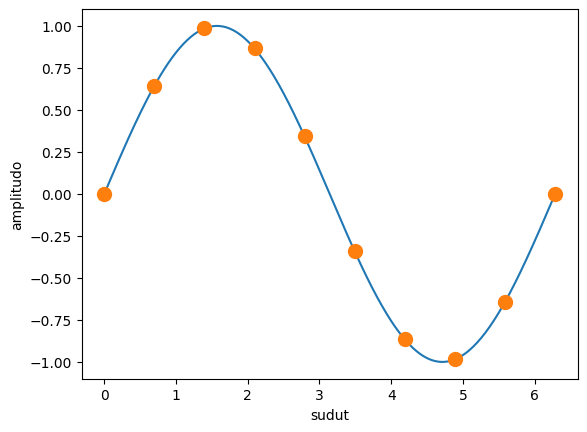

In [2]:
# mempersiapkan ruang (titik-titik sampling)

xd = np.linspace(0, 2*np.pi, 10)
yd = np.sin(xd)

# kurva yang menyerupai fungsi asli dapat dibuat dengan
# mempersiapkan ruang dengan titik-titik sampling yang rapat

xc = np.linspace(0,2*np.pi,360)
yc = np.sin(xc)

print(' Data hasil cuplik\n')
print('   x_i   y_i')
print('  ----------')
for a in zip(xd,yd):
    print(f'{a[0]:6.2f}{a[1]:6.2f}')
print('  ----------\n')

plt.plot(xc, yc, '-')
plt.plot(xd, yd, 'o', markersize=10)
plt.xlabel('sudut')
plt.ylabel('amplitudo')
plt.show()


# Interpolasi

Jika kita mengetahui bentuk fungsi dari data-data yang dicuplik dan tidak ada kesalahan pengukuran data, maka pada penggambaran kurva setiap data cuplik akan berimpit dengan kurva. Akan tetapi seringkali fungsi sebenarnya yang menghasilkan data tidak diketahui. Untuk membimbing mata untuk memperkirakan data cuplik dibuat garis penghubung antara data yang berurutan, baik menggunakan garis maupun menggunakan kurva. Penggunaan garis untuk menghubungkan titik-titik data adalah yang paling sederhana. 

Garis antara dua titik dapat digambarkan dengan menghitung parameter $a$ dan $b$ pada persamaan berikut,
$$
y=ax+b
$$

Dalam persamaan ini $a$ adalah kemiringan kurva (_gradient_) dan $b$ merupakan konstanta yang menentukan titik potong dengan sumbu $y$ pada saat $x=0$ (_offset_). Dengan mengetahui koordinat dari dua titik, persamaan garis yang menghubungkan titik-titik tersebut dapat diketahui. Pada data diatas, dapat dibuat penghubung garis dari titik koordinat $(0.70, 0.64)$ dan $(1.40, 0.98)$. Kita dapat menggunakan teknik eliminasi untuk menyelesaikan persamaan dengan variabel $a$ dan $b$, dengan titik-titik koordinat $x=[x_1, x_2]$ dan $y=[y_2, y_2]$, yaitu,
$$
\begin{aligned}
0.70a + b & = 0.64 \\
1.40a + b & = 0.98 
\end{aligned}
$$

Menggunakan teknik eliminasi didapat $b=0.34$ dan $a=0.43$, sehingga persamaan garis yang menhubungkan kedua titik itu adalah,
$$y=0.49x + 0.3$$


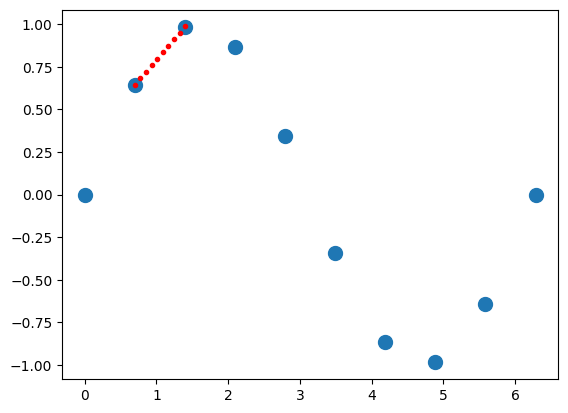

In [3]:
# buat space antara x_1 dan x_2 sebanyak 10 titik
xg = np.linspace(0.7, 1.4, 10)
yg = 0.49*xg + 0.3

plt.plot(xd, yd, 'o', markersize=10)
plt.plot(xg, yg, '.', color='red')
plt.show()

Titik titik kecil dengan warna merah adalah titik-titik interpolasi yang berada diantara dua koordinat. Untuk menghubungkan semua data dengan garis, maka diperlukan persamaan garis untuk setiap segmen. Menggunakan metode ini dapat diperkirakan nilai dari koordinat yang tidak diketahui.

Jika dilakukan perhitungan simbolik pada proses eliminasi akan didapat persamaan seperti berikut,
$$
y = \frac{y_i(x-x_j) - y_j(x-x_i)}{x_i-x_j}
$$
dengan $j=i+1$. Indeks $i$ menunjukkan nomor segmen garis, sehingga $i=0, 1, 2, ..., (n-1)$. Persamaan ini memudahkan penulisan dalam program, sehingga parameter-parameter persamaan garis penghubung tiap segmen dapat di ketahui.


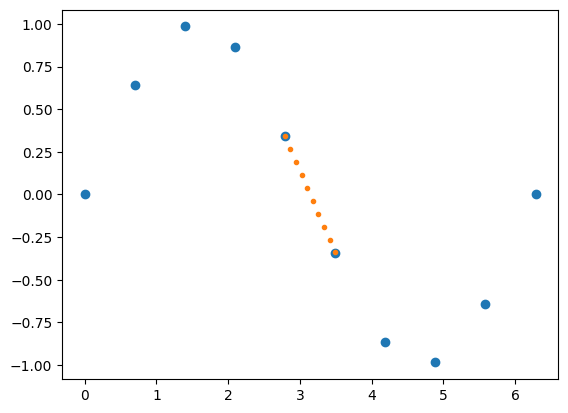

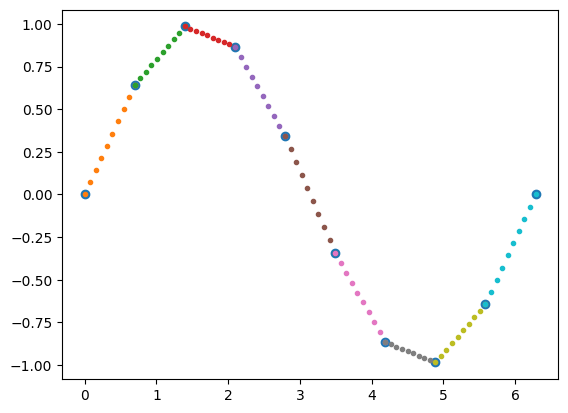

In [4]:
def segLine(x, y, n):
    xg=np.linspace(x[0], x[1], n)
    yg=(y[0]*(xg-x[1]) - y[1]*(xg-x[0]))/(x[0]-x[1])
    return xg,yg

# plot garis dari segmen ke-4
s=segLine((2.79, 3.49), (0.34, -0.34), 10)
plt.plot(xd, yd, 'o')
plt.plot(s[0], s[1], '.')
plt.show()

# plot garis untuk semua segmen
plt.plot(xd,yd, 'o')
for i in range(len(xd)-1):
    s=segLine( (xd[i], xd[i+1]), 
               (yd[i], yd[i+1]),
               10
             )
    plt.plot(s[0], s[1], '.')

plt.show()

## Interpolasi polinomial

### Polinomial Newton
Perhatikan data berikut,
$$
\begin{array}{c|cccc}
x_i & x_0 & x_1 & x_2 & x_3 \\
\hline 
y_i & y_0 & y_1 & y_2 & y_3
\end{array}
$$

Dengan menggunakan fungsi polinomial akan selalu ada fungsi, $P_n(x)$, dengan orde $n-1$ yang melalui semua titik-titik data yang diberikan, dengan $n$ jumlah data. Untuk mencari fungsi tersebut, pertama-tama hitung fungsi $s_i$, yang didefinisikan sebagai,

\begin{equation}
s_i = y_i \prod_{j=0,j\neq i}^n \frac{x-x_j}{x_i-x_j}
\end{equation}

Untuk $s_0$:

\begin{equation}
s_0 = y_0 
\frac{x-x_1}{x_0-x_1} \cdot
\frac{x-x_2}{x_0-x_2} \cdot
\frac{x-x_3}{x_0-x_3}
\end{equation}

\begin{equation}
s_1 = y_1 
\frac{x-x_0}{x_1-x_0} \cdot
\frac{x-x_2}{x_1-x_2} \cdot
\frac{x-x_3}{x_1-x_3}
\end{equation}

\begin{equation}
s_2 = y_2 
\frac{x-x_0}{x_2-x_0} \cdot
\frac{x-x_1}{x_2-x_1} \cdot
\frac{x-x_3}{x_2-x_3}
\end{equation}

\begin{equation}
s_3 = y_3 
\frac{x-x_0}{x_3-x_0} \cdot
\frac{x-x_1}{x_3-x_1} \cdot
\frac{x-x_2}{x_3-x_2}
\end{equation}


\begin{equation}
P_n(x) = \sum_{i=0}^n s_i
\end{equation}

### Implementasi program interpolasi polinomial

In [5]:
def poli(x, xd, yd):
    p=0
    N=len(yd)
    for i in range(N):
        s=yd[i]
        for j in range(N):
            if i == j: continue
            s*=(x-xd[j])/(xd[i]-xd[j])
        p+=s
    return p

def interp(x, y, n):
    # domain baru dengan resolusi lebih tinggi
    xr=np.linspace(x[0], x[-1], n)
    dd=[]
    for xi in xr:
        dd.append(poli(xi, x, y))

    return xr, np.array(dd)


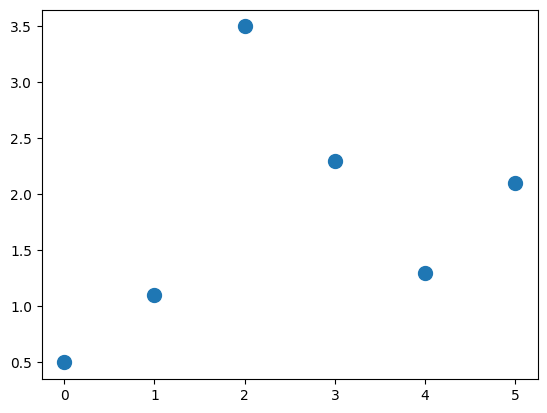

In [6]:

data=[0.5, 1.1, 3.5, 2.3, 1.3, 2.1]
xt=[0,1,2,3,4,5]

plt.plot(xt,data, 'o', markersize=10)
plt.show()

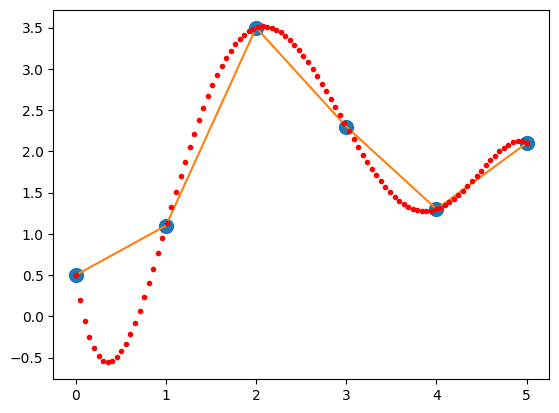

In [7]:
xr,dnew=interp(xt,data,100)

plt.plot(xt,data,'o', markersize=10)
plt.plot(xt,data,'-')
plt.plot(xr,dnew, '.', color='red')
plt.show()

### Polinom Newton untuk 2 data

$s_0=y_0\cdot \frac{x-x_1}{x_0-x_1} + y_1\cdot \frac{x-x_0}{x_1-x_0}$

$\rightarrow$ interpolasi garis (_linear_)

### Perbandingan interpolasi polinomial dengan fungsi teoretik

Jika fungsi teoretik diketahui, maka dapat dicari simpangan kurva hasil interpolasi dengan data sebenarnya, salah satunya dengan menghitung nilai kesalahan akar kuadrat (_root mean squared error_, RMSE),
$$
\epsilon_\text{RMSE} = \frac{1}{n} \sum \sqrt{(y_\text{int}-y_\text{teori})^2}
$$


kesalahan interpolasi: err=1.039539194317157e-05


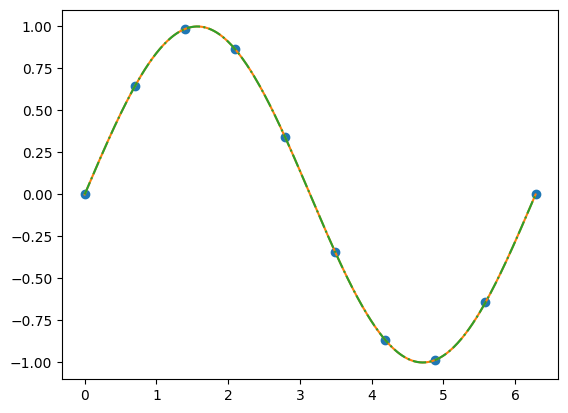

In [8]:
xi,yi=interp(xd, yd, 360)

err=sum(np.sqrt((yi-yc)**2))/360
print(f'kesalahan interpolasi: err={err}')

plt.plot(xd,yd,'o')
plt.plot(xc, yc,'-')
plt.plot(xi,yi,'-.')
plt.show()

### Pengaruh jumlah data terhadap kesalahan interpolasi

Jumlah data yang diinterpolasi berpengaruh pada nilai kesalahan. Artinya semakin sedikit data yang diberikan, fungsi polinomial semakin tidak berimpit dengan fungsi teoretik.

    4 1.054e-01
    5 8.310e-02
    6 7.342e-03
    7 5.397e-03
    8 3.269e-04
    9 2.301e-04
   10 1.040e-05


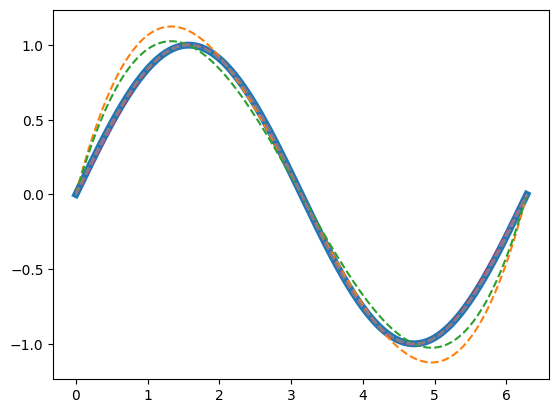

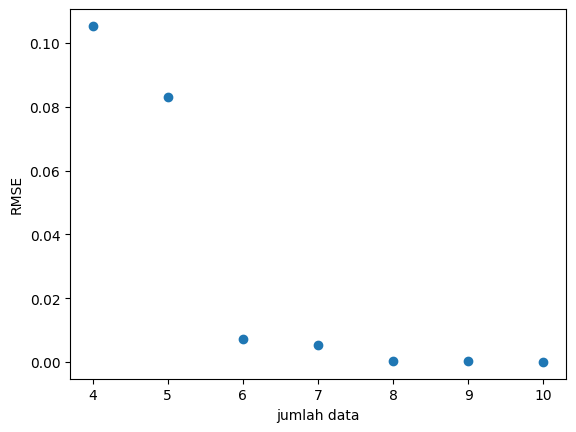

In [9]:
xc = np.linspace(0,2*np.pi,360)
yc = np.sin(xc)

plt.plot(xc,yc, linewidth=5)
nd=[4, 5, 6, 7, 8, 9, 10]
rmse=[]
for n in nd:
    xe = np.linspace(0, 2*np.pi, n)
    ye = np.sin(xe)
    xi,yi=interp(xe, ye, 360)
    err=sum(np.sqrt((yi-yc)**2))/360
    rmse.append(err)
    print(f'{n:5} {err:0.3e}')
    plt.plot(xi,yi, '--')

plt.show()

# plot RMSE
plt.plot(nd, rmse, 'o')
plt.xlabel('jumlah data')
plt.ylabel('RMSE')
plt.show()

# Cubic Spline

Kurva spline dibangun dengan mencari kurva halus dan menerus (_continue_) dari titik-titik data. Metode ini dapat menghindari osilasi yang mungkin terjadi pada interpolasi polinomial. _Cubic spline_ adalah metode membentuk kurva spline menggunakan persamaan arde-3,
$$g_i(x) = a_i (x-x_i)^3 + b_i (x-x_i)^2 + c_i(x-x_i) + d_i$$

Ini berarti dalam _cubic spline_ kontinuitas dijamin hingga turunan orde-2. Persamaan interpolasi dapat diturunkan hingga dua kali. Interpolasi ini dilakukan pada segmen-segmen data, menggunakan 3 titik tiap segmennnya. Interpolasi menghasilkan sebanyak n-1 persamaan segmen, $g_0 ... g_{n-1}$. 

* $g_i(x)$ adalah fungsi dengan koefisien $a_i,b_i,c_i,d_i$

* Syarat batas:
 * $g_i(x_i) = y_i$
 * $g_{i+1}(x_i) = y_{i+1}$
 * $g_i'(x_{i+1}) = g_{i+1}'(x_i)$
 * $g_i''(x_{i+1}) = g_{i+1}''(x_i)$


In [10]:
def calc_coef(data):
    dlen=len(data)
    # coefficients
    ca=np.zeros(dlen)
    cb=np.zeros(dlen)
    cc=np.zeros(dlen)
    cd=data.copy()

    n=dlen-2
    b=np.zeros(dlen-2)
    d=np.zeros(dlen-2)
    S=np.zeros(dlen)

    # penyelesaian matriks tridiagonal
    for i in range(1,n+1):
        d[i-1]=cd[i+1]-2.0*cd[i] + cd[i-1] # 1 2 1

    for i in range(1,n-1):
        b[i]=4

    b[0]=5.0
    b[n-1]=5.0

    for k in range(1,n):
        m=1.0/b[k-1]
        b[k]-=m
        d[k]-=m*d[k-1]

    S[n+1]=d[n-1]/b[n-1]
    S[n]=S[n+1]

    for k in range(n-2,-1,-1):
        S[k+1]=(d[k]-1.0*S[k+2])/b[k]

    S[0]=S[1]

    for i in range(dlen-1):
        ca[i]=(S[i+1]-S[i])
        cb[i]=3.0*S[i]
        cc[i]=(cd[i+1]-cd[i]-2.0*S[i]-S[i+1])

    return (cd,cc,cb,ca)


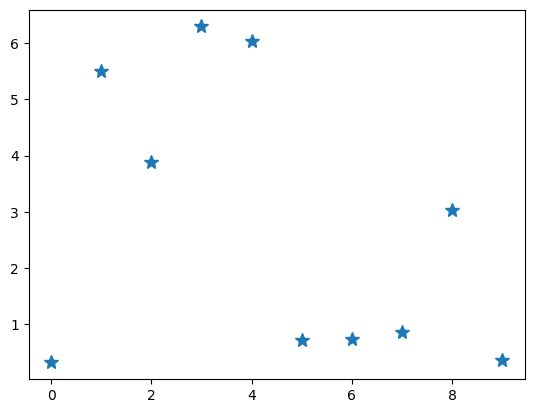

In [11]:
dtest=np.array([
    0.3167332,
    5.51185792,
    3.87859259,
    6.2972331,
    6.03537218,
    0.71630084,
    0.72811703,
    0.85544799,
    3.0308295,
    0.36050337
])

plt.plot(dtest,'*', markersize=10)
plt.show()

In [12]:
# metode pembacaan ini hanya baik untuk interpolasi
# tidak untuk mengambil fungsi turunan

def read(r,coef):
    dx=r-np.floor(r)
    x=int(r)
    if(x<0): x=0
    if(x>=len(coef[0])): x=len(coef[0])-1
    return coef[0][x]+ dx*(coef[1][x] + dx*(coef[2][x]+dx*coef[3][x]))

# nres-> resolusi data baru
def getspline(data,nres): 
    kk=calc_coef(data)
    xx,ss=[],[]
    nd=len(data)
    lim=int(nres-nres/nd)+1

    for i in range(lim):
        rr=i/(nres/nd)
        xx.append(rr)
        ss.append(read(rr,kk))
    
    return xx,ss


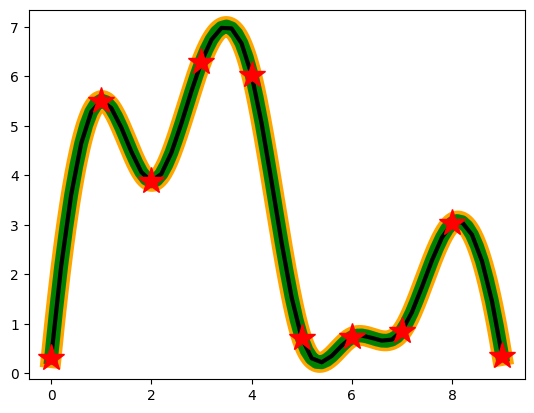

In [13]:
x,y=getspline(dtest,50)
x1,y1=getspline(dtest,100)
x2,y2=getspline(dtest,1000)

plt.plot(x2,y2, linewidth=15, color='orange')
plt.plot(x1,y1,linewidth=10, color='green')
plt.plot(x,y,linewidth=3, color='black')
plt.plot(dtest,'*', markersize=20, color='red')
plt.show()

## Menggunakan pustaka yang sudah tersedia

Python telah memiliki pustaka matematik untuk pemrosesan array dan matriks yang sangat lengkap. Fungsi-fungsi interpolasi telah tersedia dan dapat digunakan tanpa menuliskan kode secara manual.
Akan tetapi untuk tujuan instruksional pembelajaran mahasiswa diharuskan untuk belajar menuliskan fungsi sendiri.

Berikut contoh penggunaan fungsi spline dari pustaka **scipy**

In [42]:
from scipy.interpolate import interp1d as ip
xt=np.linspace(0,len(dtest), len(dtest))
fline = ip(xt,dtest, kind='linear')
fquad = ip(xt,dtest, kind='quadratic')
fspl = ip(xt,dtest,kind='cubic')

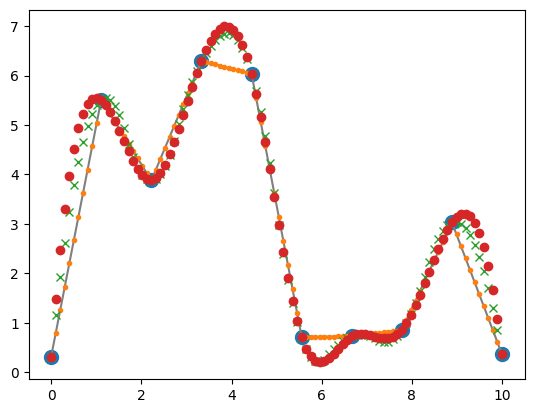

In [44]:
plt.plot(xt,dtest,'o', markersize=10)
plt.plot(xt,dtest,'-', color='gray')

xr=np.linspace(xt[0], xt[-1], 100)
plt.plot(xr,fline(xr),'.')
plt.plot(xr,fquad(xr),'x')
plt.plot(xr,fspl(xr),'o')
plt.show()